# Модуль 21. Цикл агента

Ноутбук к [модулю 21](https://drobyshevdev.github.io/lemma/modules/21-the-agent-loop/).

Цикл агента с нуля, трейс как артефакт отладки и регрессия как разница трейсов. Модель здесь — простая заглушка: важен **цикл, инструменты и трейс**, а не ум модели. Только `numpy` и `matplotlib`.

**Читайте дважды:** сначала целиком, потом ломая.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# Инструменты -- честные функции. Модель их не выполняет, а только выбирает.
KB = {("price", "виджет"): 250, ("stock", "виджет"): 3,
      ("price", "гаджет"): 80, ("stock", "гаджет"): 10}

def make_tools(price_kb=KB):
    return {
        "lookup": lambda kind, item: price_kb.get((kind, item)),
        "calc":   lambda a, b: a * b,
    }

## 1. Цикл на один экран

Модель-заглушка ведёт простую политику: не знаю цену — запроси, не знаю остаток — запроси, знаю оба — перемножь и ответь. Весь агент — это цикл `думать → вызвать инструмент → наблюдать`, пока не готов ответ.

In [2]:
def agent(item, tools, max_steps=8):
    trace = []; price = qty = None
    for _ in range(max_steps):
        if price is None:
            trace.append(("thought", "нужна цена: " + item))
            price = tools["lookup"]("price", item)
            trace += [("action", "lookup(price, %s)" % item), ("obs", str(price))]
        elif qty is None:
            trace.append(("thought", "нужен остаток: " + item))
            qty = tools["lookup"]("stock", item)
            trace += [("action", "lookup(stock, %s)" % item), ("obs", str(qty))]
        elif not isinstance(price, int) or not isinstance(qty, int):
            trace.append(("answer", "не хватает данных, не могу решить"))
            return trace, None
        else:
            total = tools["calc"](price, qty)
            trace += [("action", "calc(%d * %d)" % (price, qty)), ("obs", str(total)),
                      ("answer", "весь остаток стоит %d" % total)]
            return trace, total
    return trace, None

trace, total = agent("виджет", make_tools())
for kind, text in trace:
    print("%-9s %s" % (kind + ":", text))
print("\nитог:", total)

thought:  нужна цена: виджет
action:   lookup(price, виджет)
obs:      250
thought:  нужен остаток: виджет
action:   lookup(stock, виджет)
obs:      3
action:   calc(250 * 3)
obs:      750
answer:   весь остаток стоит 750

итог: 750


Ответ собран не одним прыжком, а по шагам, и каждый шаг виден. Нарисуем трейс как ленту: цвет — тип шага, порядок — слева направо.

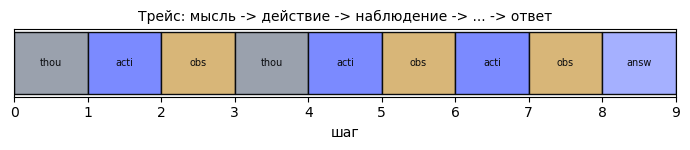

In [3]:
def draw_trace(trace, title):
    colors = {"thought": "#9aa1ad", "action": "#7b8aff", "obs": "#d8b678", "answer": "#a5b0ff"}
    fig, ax = plt.subplots(figsize=(7, 1.6))
    for i, (kind, _) in enumerate(trace):
        ax.barh(0, 1, left=i, height=0.6, color=colors[kind], edgecolor="#0a0b0e")
        ax.text(i + 0.5, 0, kind[:4], ha="center", va="center", fontsize=7, color="#0a0b0e")
    ax.set_xlim(0, len(trace)); ax.set_yticks([]); ax.set_title(title, fontsize=10)
    ax.set_xlabel("шаг"); plt.tight_layout(); plt.show()

draw_trace(trace, "Трейс: мысль -> действие -> наблюдение -> ... -> ответ")

**Сломать.** Задайте несуществующий товар (`agent("стул", make_tools())`) — `lookup` вернёт `None`, и агент честно ответит «не хватает данных». Трейс покажет, на каком шаге данные пропали.

## 2. Трейс находит место сбоя

Сломаем один инструмент: пусть склад возвращает мусор. Ответ станет бессмысленным, но по трейсу видно **точное место**, где всё пошло не так, — а не только то, что итог неверен.

In [4]:
broken = make_tools()
broken["lookup"] = lambda kind, item: (KB.get(("price", item)) if kind == "price" else "много")  # склад врёт

trace_b, total_b = agent("виджет", broken)
for kind, text in trace_b:
    print("%-9s %s" % (kind + ":", text))
print("\nитог:", total_b, "-- по трейсу видно: сбой на observation остатка ('много', не число)")

thought:  нужна цена: виджет
action:   lookup(price, виджет)
obs:      250
thought:  нужен остаток: виджет
action:   lookup(stock, виджет)
obs:      много
answer:   не хватает данных, не могу решить

итог: None -- по трейсу видно: сбой на observation остатка ('много', не число)


Итог оказался пустым, но не пришлось гадать почему: в трейсе прямо видно, что `lookup(stock)` вернул строку вместо числа, и агент честно остановился. Без трейса был бы просто неверный ответ и день на поиск причины.

**Сломать.** Пусть склад возвращает отрицательное число — агент посчитает, но ответ будет абсурдным. Трейс покажет абсурд на шаге наблюдения, до ответа.

## 3. Регрессия как разница трейсов

Две версии инструментов: в одной цена виджета изменилась. Прогоняем обе и сравниваем трейсы шаг за шагом. Регрессия — это **разница между трейсами**, ровно как в модуле 1 разница между прогонами.

In [5]:
v1 = make_tools(KB)
v2 = make_tools({**KB, ("price", "виджет"): 300})       # цена изменилась

t1, _ = agent("виджет", v1)
t2, _ = agent("виджет", v2)

print("шаг | версия 1 -> версия 2 (отличия)")
for i, (a, b) in enumerate(zip(t1, t2)):
    mark = "   <- изменилось" if a != b else ""
    print("%2d  | %-28s %s%s" % (i, "%s: %s" % a, ("%s: %s" % b) if a != b else "=", mark))

шаг | версия 1 -> версия 2 (отличия)
 0  | thought: нужна цена: виджет  =
 1  | action: lookup(price, виджет) =
 2  | obs: 250                     obs: 300   <- изменилось
 3  | thought: нужен остаток: виджет =
 4  | action: lookup(stock, виджет) =
 5  | obs: 3                       =
 6  | action: calc(250 * 3)        action: calc(300 * 3)   <- изменилось
 7  | obs: 750                     obs: 900   <- изменилось
 8  | answer: весь остаток стоит 750 answer: весь остаток стоит 900   <- изменилось


Diff трейсов точечно показывает, что изменилось: наблюдение цены, а за ним итог. Так устроена регрессия агента — не «стало хуже вообще», а конкретный шаг, где поведение разошлось. Именно это в [модуле 23](https://drobyshevdev.github.io/lemma/programme/) станет eval: golden-трейс как эталон, diff как сигнал регрессии.

## Что дальше

В [модуле 22](https://drobyshevdev.github.io/lemma/programme/) инструмент «поиск» из этого цикла вырастает в полноценную подсистему: RAG, гибридный поиск, реранкер и проверка цитат — как сделать ответ, который нельзя выдумать, привязав каждое утверждение к источнику.